In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, RobustScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.ensemble import IsolationForest
import shap
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.insert(0, os.path.abspath(".."))
from scaling import scale_features
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from config import load_data, FEATURES, SKEWED, FRAUD_IDS

from waiter_models import compare_waiter_models

In [82]:
df, client_data = load_data(activity_state=2, days_visits=2)

df['gross_amount_90'] = df['place_id'].map(df.groupby('place_id')['gross_amount'].quantile(0.9))
df['gross_amount_95'] = df['place_id'].map(df.groupby('place_id')['gross_amount'].quantile(0.95))

df['exp_90'] = df['gross_amount'] >= df['gross_amount_90']
df['exp_95'] = df['gross_amount'] >= df['gross_amount_95']

In [ ]:
# --- Client-level: get anomaly scores (fit on all or non-fraud only) ---
from waiter_models import fit_and_evaluate


train_mask = ~client_data["is_fraud"].values
train_data = client_data.loc[train_mask]
X_fit_cl, X_eval_cl = scale_features(
    data=client_data,
    scaler_type="standard",
    features=FEATURES,
    skewed=SKEWED,
    fit_data=train_data,
)
y_client = client_data["is_fraud"].astype(int).values
_, _, scores_cl = fit_and_evaluate(
    X_fit_cl.values,
    y_client,
    FRAUD_IDS,
    client_data.index,
    X_eval=X_eval_cl.values,
)
anomaly_scores = pd.DataFrame(
{
    "anomaly_score_iso": scores_cl["iso"],
    "anomaly_score_ocsvm": scores_cl["ocsvm"],
    "anomaly_score_lof": scores_cl["lof"],
},
index=client_data.index,
)
client_data = client_data.merge(anomaly_scores, left_index=True, right_index=True)
df = df.merge(anomaly_scores, left_on="person_id", right_index=True, how="left")
fraud_waiter_ids = client_data[client_data["is_fraud"] == 1]["top_waiter_id"].dropna().unique()

In [84]:
def _build_waiter_data(df: pd.DataFrame, client_data: pd.DataFrame) -> pd.DataFrame:
    """
    Build waiter-level DataFrame from transaction df and client_data (with anomaly scores).
    client_data must have anomaly_score_iso, anomaly_score_ocsvm, anomaly_score_lof, top_waiter_id, num_of_trn, days_visits.
    df must have person_id, waiter_id, place_id, date, trn_id and the same anomaly score columns after merge.
    """
    # Merge anomaly scores from client_data into df (df has person_id)
    if "anomaly_score_iso" not in df.columns and "anomaly_score_iso" in client_data.columns:
        scores = client_data[["anomaly_score_iso", "anomaly_score_ocsvm", "anomaly_score_lof"]]
        df = df.merge(scores, left_on="person_id", right_index=True, how="left")
    elif "anomaly_score_iso" not in df.columns:
        raise ValueError("Anomaly scores must be in df or client_data")
    waiter_data = df.groupby("waiter_id").agg(
        iso_90=("anomaly_score_iso", lambda x: x.quantile(0.9)),
        ocsvm_90=("anomaly_score_ocsvm", lambda x: x.quantile(0.9)),
        lof_90=("anomaly_score_lof", lambda x: x.quantile(0.9)),
        num_of_trn=("trn_id", "nunique"),
        num_of_clients=("person_id", "nunique"),
        working_days=("date", "nunique"),
        bonusses_accum = ('bonusses_accum', 'sum'),
        bonusses_used = ('bonusses_used', 'sum'),

        discount_trn = ('bonus_used_flag', 'sum'),

        first_transactions = ('trn_count_before', lambda x: (x == 0).sum()),

        exp_90 = ('exp_90', 'sum'), #num of transactions with gross amount >= 90th percentile
        exp_95 = ('exp_95', 'sum'), #num of transactions with gross amount >= 95th percentile
    ).reset_index()

    waiter_data["is_fraud"] = waiter_data["waiter_id"].isin(fraud_waiter_ids)

    active_person_ids = client_data[
        (client_data["num_of_trn"] > 5) & (client_data["days_visits"] > 5)
    ].index

    active_clients_per_waiter = (
        df[df["person_id"].isin(active_person_ids)]
        .groupby("waiter_id")["person_id"]
        .nunique()
        .rename("num_of_active_clients")
    )
    waiter_data = waiter_data.merge(
        active_clients_per_waiter, left_on="waiter_id", right_index=True, how="left"
    )
    waiter_data["num_of_active_clients"] = waiter_data["num_of_active_clients"].fillna(0).astype(int)

    person_place_waiter = (
        df.groupby(["person_id", "place_id"])["waiter_id"]
        .nunique()
        .reset_index(name="num_waiters_in_place")
    )
    single_waiter_person_place = person_place_waiter[
        person_place_waiter["num_waiters_in_place"] == 1
    ][["person_id", "place_id"]]
    person_place_waiter_map = df[["person_id", "place_id", "waiter_id"]].drop_duplicates()
    single_waiter_records = single_waiter_person_place.merge(
        person_place_waiter_map, on=["person_id", "place_id"], how="left"
    )

    clients_only_this_waiter = (
        single_waiter_records.groupby("waiter_id")["person_id"]
        .nunique()
        .rename("num_clients_only_this_waiter")
    )
    waiter_data = waiter_data.merge(
        clients_only_this_waiter, left_on="waiter_id", right_index=True, how="left"
    )
    waiter_data["num_clients_only_this_waiter"] = (
        waiter_data["num_clients_only_this_waiter"].fillna(0).astype(int)
    )

    single_waiter_active_records = single_waiter_records[
        single_waiter_records["person_id"].isin(active_person_ids)
    ]
    active_clients_only_this_waiter = (
        single_waiter_active_records.groupby("waiter_id")["person_id"]
        .nunique()
        .rename("num_active_clients_only_this_waiter")
    )
    waiter_data = waiter_data.merge(
        active_clients_only_this_waiter, left_on="waiter_id", right_index=True, how="left"
    )
    waiter_data["num_active_clients_only_this_waiter"] = (
        waiter_data["num_active_clients_only_this_waiter"].fillna(0).astype(int)
    )

    person_waiter = (
        df.groupby("person_id")["waiter_id"].nunique().reset_index(name="num_waiters_total")
    )
    single_waiter_total_persons = person_waiter[person_waiter["num_waiters_total"] == 1][["person_id"]]
    person_waiter_total_map = df[["person_id", "waiter_id"]].drop_duplicates()
    single_waiter_total_records = single_waiter_total_persons.merge(
        person_waiter_total_map, on="person_id", how="left"
    )

    clients_single_waiter_total = (
        single_waiter_total_records.groupby("waiter_id")["person_id"]
        .nunique()
        .rename("num_clients_single_waiter_total")
    )
    waiter_data = waiter_data.merge(
        clients_single_waiter_total, left_on="waiter_id", right_index=True, how="left"
    )
    waiter_data["num_clients_single_waiter_total"] = (
        waiter_data["num_clients_single_waiter_total"].fillna(0).astype(int)
    )

    single_waiter_total_active_records = single_waiter_total_records[
        single_waiter_total_records["person_id"].isin(active_person_ids)
    ]
    active_clients_single_waiter_total = (
        single_waiter_total_active_records.groupby("waiter_id")["person_id"]
        .nunique()
        .rename("num_active_clients_single_waiter_total")
    )
    waiter_data = waiter_data.merge(
        active_clients_single_waiter_total, left_on="waiter_id", right_index=True, how="left"
    )
    waiter_data["num_active_clients_single_waiter_total"] = (
        waiter_data["num_active_clients_single_waiter_total"].fillna(0).astype(int)
    )

    waiter_data["share_clients_only_this_waiter"] = (
        waiter_data["num_clients_only_this_waiter"] / waiter_data["num_of_clients"]
    ).fillna(0)
    waiter_data["share_active_clients_only_this_waiter"] = (
        waiter_data["num_active_clients_only_this_waiter"]
        / waiter_data["num_of_active_clients"].replace(0, np.nan)
    ).fillna(0)
    waiter_data["share_clients_single_waiter_total"] = (
        waiter_data["num_clients_single_waiter_total"] / waiter_data["num_of_clients"]
    ).fillna(0)
    waiter_data["share_active_clients_single_waiter_total"] = (
        waiter_data["num_active_clients_single_waiter_total"]
        / waiter_data["num_of_active_clients"].replace(0, np.nan)
    ).fillna(0)


    waiter_place_map = df[['waiter_id', 'place_id']].drop_duplicates()
    waiter_data = waiter_data.merge(waiter_place_map, on='waiter_id', how='left')
    place_partnes_map = df[['place_id', 'partner_id']].drop_duplicates()
    waiter_data = waiter_data.merge(place_partnes_map, on='place_id', how='left')

    waiter_data['share_new_clients'] = waiter_data['first_transactions'] / waiter_data['num_of_clients']

    # Normalize 'bonusses_accum' to mean value by 'place_id'
    waiter_data['bonusses_accum_norm'] = waiter_data['bonusses_accum'] / waiter_data.groupby('place_id')['bonusses_accum'].transform('mean')
    waiter_data['bonusses_used_norm'] = waiter_data['bonusses_used'] / waiter_data.groupby('place_id')['bonusses_used'].transform('mean')
    waiter_data['bonusses_used_to_accum_norm'] = waiter_data['bonusses_used_norm'] / waiter_data['bonusses_accum_norm']

    waiter_data['share_discount_trn'] = waiter_data['discount_trn'] / waiter_data['num_of_trn']

    ### gross amount
    waiter_data['exp_90_norm'] = waiter_data['exp_90'] / waiter_data.groupby('place_id')['exp_90'].transform('mean')
    waiter_data['exp_95_norm'] = waiter_data['exp_95'] / waiter_data.groupby('place_id')['exp_95'].transform('mean')

    waiter_data['share_exp_90'] = waiter_data['exp_90'] / waiter_data['num_of_trn']
    waiter_data['share_exp_95'] = waiter_data['exp_95'] / waiter_data['num_of_trn']


    df = df.sort_values(['waiter_id', 'trn_date'])

    df['time_diff'] = (
        df.groupby(['waiter_id', 'date'])['trn_date']
        .diff()
        .dt.total_seconds()
    )
    time_between_trn_per_day = (
        df.groupby(['waiter_id', 'date'])['time_diff']
        .median()
        .div(60)
        .reset_index(name='median_time_between_trn_min')
    )
    time_between_trn_per_day[time_between_trn_per_day['waiter_id'] == '675ac8c769a6f18612504814_19362']
    median_time = time_between_trn_per_day.groupby('waiter_id')['median_time_between_trn_min'].mean().reset_index(name='median_time')

    waiter_data = waiter_data.merge(median_time, on='waiter_id', how='left')


    return waiter_data

In [85]:
waiter_data = _build_waiter_data(df, client_data)
waiter_data = waiter_data.set_index("waiter_id")

### func

In [10]:
WAITER_FEATURES = ['iso_90', 'ocsvm_90', 'lof_90']
WAITER_SKEWED = []

In [ ]:
def compare_waiter_models(
    activity_state: int = 2,
    days_visits: int = 2,
    min_working_days: int = 20,
    exclude_fraud_from_training: bool = True,
    # plot_scores_path: None,
    waiter_features: list = WAITER_FEATURES,
    waiter_skewed: list = WAITER_SKEWED,
    agg_data: pd.DataFrame = waiter_data,
    fraud_waiter_ids: list = FRAUD_WAITER_IDS,
):
    """
    Load client data, compute client-level anomaly scores, build waiter-level features,
    then run Isolation Forest, One-Class SVM, and LOF on waiters. Print same metrics as models.py:
    hit_rate, recall@k, precision@k, n_anomalies, pct_flagged, time_sec.
    """
    agg_data = agg_data[agg_data["working_days"] > min_working_days].copy()

    # fraud_ids = client_data[client_data["is_fraud"] == 1]["top_waiter_id"].dropna().unique()
    agg_data["is_fraud"] = agg_data.index.isin(fraud_waiter_ids)
    y_fraud = agg_data["is_fraud"].astype(int).values
    n_fraud = y_fraud.sum()
    n_total = len(agg_data)

    if exclude_fraud_from_training:
        non_fraud_waiters = agg_data[~agg_data["is_fraud"]]
        X_fit_df, X_eval_df = scale_features(
            data=agg_data,
            features=waiter_features,
            skewed=waiter_skewed,
            scaler_type="standard",
            fit_data=non_fraud_waiters,
        )
        X_fit = X_fit_df.values
        X_eval = X_eval_df.values
        n_train = len(non_fraud_waiters)
    else:
        X_full = scale_features(
            data=agg_data,
            features=waiter_features,
            skewed=waiter_skewed,
            scaler_type="standard",
        )
        X_fit = X_eval = np.asarray(X_full.values, dtype=np.float64)
        n_train = n_total

    results_df, predictions, scores, perm_importance = fit_and_evaluate(
        X_fit,
        y_fraud,
        fraud_waiter_ids,
        agg_data.index,
        X_eval=X_eval,
        compute_permutation_importance=True,
        n_repeats_perm=5,
    )

    print("=" * 60)
    print("Waiter anomaly detection — model comparison")
    print("=" * 60)
    print(f"Samples (total): {n_total}  |  Known fraud waiters: {n_fraud}")
    if exclude_fraud_from_training:
        print(f"Training on non-fraud waiters only: {n_train} samples")
    else:
        print("Training on full data (fraud included in training)")
    print(f"Features: {waiter_features}")
    print(f"Filter: working_days > {min_working_days}")
    print()
    print(results_df.to_string(index=False))
    print()
    print("Metrics:")
    print("  - n_anomalies: number of waiters flagged as anomaly (-1)")
    print("  - pct_flagged: percentage of all waiters flagged")
    print("  - fraud_hit_rate: fraction of known fraud waiters correctly flagged as anomaly")
    print("  - recall@k: fraction of known fraud waiters in the top k by anomaly score (k=10,20,50,100)")
    print("  - precision@k: fraction of top k by anomaly score that are known fraud waiters (k=10,20,50,100)")
    print("  - time_sec: fit+predict time in seconds")
    print()

    fraud_mask = agg_data["is_fraud"].values
    fraud_index = np.where(fraud_mask)[0]
    print("Known fraud waiters — which model flagged them (-1 = anomaly):")
    print("-" * 60)
    for i in fraud_index:
        wid = agg_data.index[i]
        row = (
            f"  waiter_id={wid}: "
            f"IF={predictions['iso'][i]}, OCSVM={predictions['ocsvm'][i]}, LOF={predictions['lof'][i]}"
        )
        print(row)
    print()

    # if plot_scores_path:
    #     _client_models._plot_anomaly_score_distributions(scores, y_fraud, plot_scores_path)
    #     print(f"Anomaly score distributions saved to {plot_scores_path}")

    X_out = pd.DataFrame(X_eval, index=agg_data.index, columns=waiter_features)
    return results_df, predictions, agg_data, X_out


### 1st try

| Model             | Recall@20 |
|------------------|----------|
| Isolation Forest | 0.3750   |
| One-Class SVM    | 0.3125   |
| LOF              | 0.1875   |

In [ ]:
WAITER_FEATURES = ['iso_90', 'ocsvm_90', 'lof_90']
WAITER_SKEWED = []
result_df, _, agg_data, X_out = compare_waiter_models(waiter_features = WAITER_FEATURES, min_working_days=20, agg_data=waiter_data, fraud_waiter_ids = fraud_waiter_ids)

Waiter anomaly detection — model comparison
Samples (total): 2609  |  Known fraud waiters: 16
Training on non-fraud waiters only: 2593 samples
Features: ['iso_90', 'ocsvm_90', 'lof_90']
Filter: working_days > 20

           model  n_anomalies  pct_flagged  fraud_hit_rate  time_sec  recall@10  recall@20  recall@50  recall@100  precision@10  precision@20  precision@50  precision@100
Isolation Forest            4     0.153315          0.0625     0.089     0.2500     0.3750     0.4375      0.4375           0.4          0.30          0.14           0.07
   One-Class SVM           44     1.686470          0.3125     0.010     0.3125     0.3125     0.3125      0.3125           0.5          0.25          0.10           0.05
             LOF            4     0.153315          0.0625     0.038     0.0625     0.1875     0.2500      0.3750           0.1          0.15          0.08           0.06

Metrics:
  - n_anomalies: number of waiters flagged as anomaly (-1)
  - pct_flagged: percentage of all

### 2nd try

| Model             | Recall@20 |
|------------------|----------|
| Isolation Forest | 0.3125   |
| One-Class SVM    | 0.3750   |
| LOF              | 0.1250   |

In [129]:
WAITER_FEATURES = ['iso_90', 'ocsvm_90', 'lof_90', 'share_clients_only_this_waiter']
WAITER_SKEWED = []
result_df, _, agg_data, X_out, perm_results = compare_waiter_models(
    waiter_features=WAITER_FEATURES,
    min_working_days=20,
    agg_data=waiter_data,
    fraud_waiter_ids=fraud_waiter_ids
)

Waiter anomaly detection — model comparison
Samples (total): 2609  |  Known fraud waiters: 16
Training on non-fraud waiters only: 2593 samples
Features: ['iso_90', 'ocsvm_90', 'lof_90', 'share_clients_only_this_waiter']
Filter: working_days > 20

           model  n_anomalies  pct_flagged  fraud_hit_rate  time_sec  recall@10  recall@20  recall@50  recall@100  precision@10  precision@20  precision@50  precision@100
Isolation Forest            6     0.229973          0.1875     0.083     0.1875     0.3125     0.4375      0.4375           0.3          0.25          0.14           0.07
   One-Class SVM           44     1.686470          0.3750     0.012     0.3750     0.3750     0.3750      0.3750           0.6          0.30          0.12           0.06
             LOF            3     0.114987          0.0625     0.054     0.0625     0.1250     0.3125      0.3750           0.1          0.10          0.10           0.06

Metrics:
  - n_anomalies: number of waiters flagged as anomaly (-1)


### 3rd Try

| Model             | Recall@20 |
|------------------|----------|
| Isolation Forest | 0.2500   |
| One-Class SVM    | 0.4375   |
| LOF              | 0.2500   |

In [134]:
WAITER_FEATURES = ['iso_90', 'ocsvm_90', 'lof_90', 'num_active_clients_single_waiter_total']
WAITER_SKEWED = []
result_df, _, agg_data, X_out, perm_results = compare_waiter_models(
    waiter_features=WAITER_FEATURES,
    min_working_days=20,
    agg_data=waiter_data,
    fraud_waiter_ids=fraud_waiter_ids
)

Waiter anomaly detection — model comparison
Samples (total): 2609  |  Known fraud waiters: 16
Training on non-fraud waiters only: 2593 samples
Features: ['iso_90', 'ocsvm_90', 'lof_90', 'num_active_clients_single_waiter_total']
Filter: working_days > 20

           model  n_anomalies  pct_flagged  fraud_hit_rate  time_sec  recall@10  recall@20  recall@50  recall@100  precision@10  precision@20  precision@50  precision@100
Isolation Forest            4     0.153315          0.0625     0.111     0.1875     0.2500     0.4375      0.5000           0.3          0.20          0.14           0.08
   One-Class SVM           49     1.878114          0.4375     0.010     0.4375     0.4375     0.4375      0.5000           0.7          0.35          0.14           0.08
             LOF            3     0.114987          0.0625     0.064     0.1250     0.2500     0.3750      0.4375           0.2          0.20          0.12           0.07

Metrics:
  - n_anomalies: number of waiters flagged as anoma

### 4th Try

| Model             | Recall@20 |
|------------------|----------|
| Isolation Forest | 0.2500   |
| One-Class SVM    | 0.4375   |
| LOF              | 0.3125   |

In [133]:
WAITER_FEATURES = ['iso_90', 'ocsvm_90', 'lof_90', 'num_active_clients_single_waiter_total', 'share_clients_only_this_waiter']
WAITER_SKEWED = []
result_df, _, agg_data, X_out, perm_results = compare_waiter_models(
    waiter_features=WAITER_FEATURES,
    min_working_days=20,
    agg_data=waiter_data,
    fraud_waiter_ids=fraud_waiter_ids
)

Waiter anomaly detection — model comparison
Samples (total): 2609  |  Known fraud waiters: 16
Training on non-fraud waiters only: 2593 samples
Features: ['iso_90', 'ocsvm_90', 'lof_90', 'num_active_clients_single_waiter_total', 'share_clients_only_this_waiter']
Filter: working_days > 20

           model  n_anomalies  pct_flagged  fraud_hit_rate  time_sec  recall@10  recall@20  recall@50  recall@100  precision@10  precision@20  precision@50  precision@100
Isolation Forest            5     0.191644          0.1250     0.077     0.1875     0.2500     0.4375      0.5625           0.3          0.20          0.14           0.09
   One-Class SVM           46     1.763128          0.4375     0.015     0.4375     0.4375     0.4375      0.5000           0.7          0.35          0.14           0.08
             LOF            5     0.191644          0.1250     0.095     0.1250     0.3125     0.3750      0.4375           0.2          0.25          0.12           0.07

Metrics:
  - n_anomalies: 

### 4th Try

| Model             | Recall@20 |
|------------------|----------|
| Isolation Forest | 0.2500   |
| One-Class SVM    | 0.4375   |
| LOF              | 0.3125   |

In [ ]:
WAITER_FEATURES = [
    'iso_90', 'ocsvm_90', 'lof_90', 'num_of_trn', 'num_of_clients',
    'bonusses_accum', 'bonusses_used', 'discount_trn',
    'exp_90', 'exp_95',
    'num_of_active_clients', 'num_clients_only_this_waiter',
    'num_active_clients_only_this_waiter',
    'num_clients_single_waiter_total',
    'share_active_clients_only_this_waiter',
    'share_active_clients_single_waiter_total',
    'bonusses_used_norm',
    'exp_90_norm', 'exp_95_norm', 'share_exp_95',
]
WAITER_SKEWED = []

# Run the model comparison as before
result_df, models_dict, agg_data, X_out = compare_waiter_models(
    waiter_features=WAITER_FEATURES,
    min_working_days=20,
    agg_data=waiter_data,
    fraud_waiter_ids=fraud_waiter_ids
)

Waiter anomaly detection — model comparison
Samples (total): 2609  |  Known fraud waiters: 16
Training on non-fraud waiters only: 2593 samples
Features: ['iso_90', 'ocsvm_90', 'lof_90', 'num_of_trn', 'num_of_clients', 'bonusses_accum', 'bonusses_used', 'discount_trn', 'exp_90', 'exp_95', 'num_of_active_clients', 'num_clients_only_this_waiter', 'num_active_clients_only_this_waiter', 'num_clients_single_waiter_total', 'share_active_clients_only_this_waiter', 'share_active_clients_single_waiter_total', 'bonusses_used_norm', 'exp_90_norm', 'exp_95_norm', 'share_exp_95']
Filter: working_days > 20

           model  n_anomalies  pct_flagged  fraud_hit_rate  time_sec  recall@10  recall@20  recall@50  recall@100  precision@10  precision@20  precision@50  precision@100
Isolation Forest            3     0.114987          0.0000     0.130     0.0000     0.0625     0.0625      0.3125           0.0          0.05          0.02           0.05
   One-Class SVM           79     3.027980          0.5625

## Feature importance: permutation importance and other methods

After running `compare_waiter_models`, we refit the same models and compute:
- **Permutation importance**: drop in ROC-AUC (anomaly score vs fraud label) when each feature is shuffled.
- **SHAP** (for Isolation Forest): TreeExplainer to get per-feature contributions.
- **Model-specific**: Isolation Forest's `feature_importances_` via the internal estimators (if available).

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor

# Use scaled features and labels from the last compare_waiter_models run
feature_names = list(X_out.columns)
X_eval = np.asarray(X_out.values, dtype=np.float64)
y_eval = agg_data["is_fraud"].astype(int).values
train_mask = ~agg_data["is_fraud"].values
X_fit = X_eval[train_mask]

contamination = 0.001
n_neighbors = min(50, len(X_fit) - 1)
if n_neighbors < 5:
    n_neighbors = 5

# --- Fit the same three models (so we have estimators for importance) ---
iso = IsolationForest(n_estimators=100, contamination=contamination, random_state=42, n_jobs=-1)
iso.fit(X_fit)

ocsvm = OneClassSVM(kernel="rbf", nu=0.001, gamma="scale")
max_ocsvm_train = 4000
if len(X_fit) > max_ocsvm_train:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_fit), size=max_ocsvm_train, replace=False)
    ocsvm.fit(X_fit[idx])
else:
    ocsvm.fit(X_fit)

lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, metric="minkowski", p=2, novelty=True)
lof.fit(X_fit)

# Scorer: ROC-AUC of anomaly score vs fraud label (higher score = more anomalous, so we use negative score for "predict" direction)
def _anomaly_score_iso(est, X):
    return -est.score_samples(X)
def _anomaly_score_ocsvm(est, X):
    return -est.decision_function(X)
def _anomaly_score_lof(est, X):
    return -est.score_samples(X)

def make_auc_scorer(get_scores):
    def scorer(estimator, X, y):
        s = get_scores(estimator, X)
        if np.all(np.isnan(s)) or len(np.unique(y)) < 2:
            return 0.0
        return roc_auc_score(y, s)
    return scorer

# --- Permutation importance (n_repeats=5 to keep runtime reasonable) ---
n_repeats = 5
random_state_perm = 42

perm_iso = permutation_importance(
    iso, X_eval, y_eval,
    scoring=make_auc_scorer(_anomaly_score_iso),
    n_repeats=n_repeats,
    random_state=random_state_perm,
    n_jobs=-1,
)
perm_ocsvm = permutation_importance(
    ocsvm, X_eval, y_eval,
    scoring=make_auc_scorer(_anomaly_score_ocsvm),
    n_repeats=n_repeats,
    random_state=random_state_perm,
    n_jobs=-1,
)
perm_lof = permutation_importance(
    lof, X_eval, y_eval,
    scoring=make_auc_scorer(_anomaly_score_lof),
    n_repeats=n_repeats,
    random_state=random_state_perm,
    n_jobs=-1,
)

# Collect into DataFrames for comparison
perm_results = {
    "Isolation Forest": pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_iso.importances_mean,
        "importance_std": perm_iso.importances_std,
    }).sort_values("importance_mean", ascending=False),
    "One-Class SVM": pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_ocsvm.importances_mean,
        "importance_std": perm_ocsvm.importances_std,
    }).sort_values("importance_mean", ascending=False),
    "LOF": pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_lof.importances_mean,
        "importance_std": perm_lof.importances_std,
    }).sort_values("importance_mean", ascending=False),
}
# Display permutation importance tables
for name, df_perm in perm_results.items():
    print(f"=== {name} (permutation importance, drop in ROC-AUC) ===\n")
    print(df_perm.to_string(index=False))
    print()



=== Isolation Forest (permutation importance, drop in ROC-AUC) ===

                                 feature  importance_mean  importance_std
                                  iso_90         0.024798        0.011226
                                ocsvm_90         0.019066        0.003730
                             exp_95_norm         0.016872        0.010743
                          bonusses_accum         0.013146        0.010366
                           bonusses_used         0.012143        0.018762
                                  exp_95         0.010254        0.024530
   share_active_clients_only_this_waiter         0.005958        0.005542
                      bonusses_used_norm         0.005240        0.019392
share_active_clients_single_waiter_total         0.005004        0.004829
                          num_of_clients         0.004695        0.019438
         num_clients_single_waiter_total         0.004252        0.020486
                            discount_trn    

In [ ]:
# Plot permutation importance (horizontal bar, one subplot per model)
fig = make_subplots(rows=1, cols=3, subplot_titles=list(perm_results.keys()), horizontal_spacing=0.12)
for col, (model_name, df_perm) in enumerate(perm_results.items(), start=1):
    df_perm = df_perm.sort_values("importance_mean", ascending=True)  # top at top
    fig.add_trace(
        go.Bar(
            y=df_perm["feature"],
            x=df_perm["importance_mean"],
            error_x=dict(type="data", array=df_perm["importance_std"]),
            orientation="h",
            name=model_name,
        ),
        row=1, col=col,
    )
fig.update_layout(height=max(400, len(feature_names) * 12), title_text="Permutation importance (drop in ROC-AUC when feature shuffled)")
fig.update_xaxes(title_text="Importance (drop in AUC)", row=1, col=1)
fig.update_xaxes(title_text="Importance (drop in AUC)", row=1, col=2)
fig.update_xaxes(title_text="Importance (drop in AUC)", row=1, col=3)
fig.show()

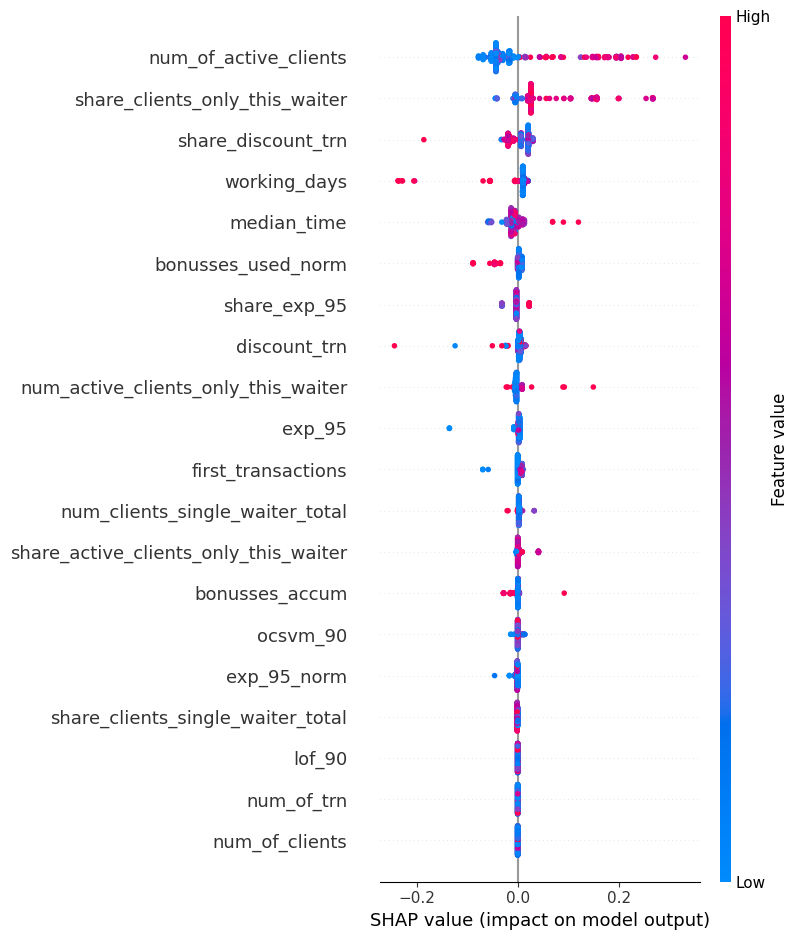

In [155]:
# --- SHAP for Isolation Forest (TreeExplainer on one tree as proxy for feature importance) ---
# Full ensemble SHAP would require model-agnostic explainer (slow). We use the first tree for a quick view.
n_background = min(100, len(X_eval))
rng = np.random.default_rng(42)
background_idx = rng.choice(len(X_eval), size=n_background, replace=False)
X_background = X_eval[background_idx]

try:
    explainer_iso = shap.TreeExplainer(iso.estimators_[0], data=X_background)
    shap_values_one_tree = explainer_iso.shap_values(X_eval[: min(300, len(X_eval))])
    shap.summary_plot(shap_values_one_tree, X_eval[: min(300, len(X_eval))], feature_names=feature_names, show=False)
except Exception as e:
    print("SHAP TreeExplainer (one tree) failed:", e)

In [156]:
# --- Visualization: Correlation and Mutual Information with Fraud Label ---
from sklearn.feature_selection import mutual_info_classif
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate correlation (absolute) of each feature with is_fraud
corr_with_fraud = pd.Series(
    np.abs(np.corrcoef(X_eval.T, y_eval)[:-1, -1]),
    index=feature_names,
).sort_values(ascending=False)

# Calculate mutual information
mi = mutual_info_classif(X_eval, y_eval, random_state=42)
mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)

# Visualize as horizontal bar plots side by side
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["|Feature Correlation with is_fraud|", "Mutual Information with is_fraud"]
)

# Correlation plot
fig.add_trace(
    go.Bar(
        y=corr_with_fraud.index,
        x=corr_with_fraud.values,
        orientation='h',
        marker_color='steelblue',
        name="|Correlation|"
    ),
    row=1, col=1
)

# Mutual info plot
fig.add_trace(
    go.Bar(
        y=mi_series.index,
        x=mi_series.values,
        orientation='h',
        marker_color='indianred',
        name="Mutual Info"
    ),
    row=1, col=2
)

fig.update_yaxes(
    automargin=True,
    categoryorder='array',
    categoryarray=corr_with_fraud.index[::-1],  # Keep same order for both
    row=1, col=1
)
fig.update_yaxes(
    automargin=True,
    categoryorder='array',
    categoryarray=mi_series.index[::-1],
    row=1, col=2
)
fig.update_xaxes(title_text="|Correlation|", row=1, col=1)
fig.update_xaxes(title_text="Mutual information", row=1, col=2)
fig.update_layout(
    title_text="Feature Correlation and Mutual Information with Fraud Label",
    height=max(400, len(feature_names)*18), showlegend=False
)
fig.show()

### Vizzzz

In [126]:
# df['place_id'].value_counts()
fraud_places = df[df['waiter_id'].isin(fraud_waiter_ids)]['place_id'].value_counts().index.tolist()

In [127]:
waiter_data_20 = waiter_data[(waiter_data['working_days']>20) & (waiter_data['place_id'].isin(fraud_places))] 

features_to_vis = [
    'iso_90', 'ocsvm_90', 'lof_90', 'num_of_trn', 'num_of_clients',
    'working_days', 'bonusses_accum', 'bonusses_used', 'discount_trn',
    'first_transactions', 'exp_90', 'exp_95',
    'num_of_active_clients', 'num_clients_only_this_waiter',
    'num_active_clients_only_this_waiter',
    'num_clients_single_waiter_total',
    'num_active_clients_single_waiter_total',
    'share_clients_only_this_waiter',
    'share_active_clients_only_this_waiter',
    'share_clients_single_waiter_total',
    'share_active_clients_single_waiter_total',
    'share_new_clients', 'bonusses_accum_norm', 'bonusses_used_norm',
    'bonusses_used_to_accum_norm', 'share_discount_trn', 'exp_90_norm',
    'exp_95_norm', 'share_exp_90', 'share_exp_95', 'median_time'
]

import math

num_features = len(features_to_vis)
cols = 3
rows = math.ceil(num_features / cols)

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=features_to_vis,
)

for idx, feature in enumerate(features_to_vis):
    r = idx // cols + 1  
    c = idx % cols + 1  
    
    for is_fraud_val, fraud_text, color in zip([0,1], ['Non-Fraud', 'Fraud'], px.colors.qualitative.Set2):
        filtered = waiter_data_20[waiter_data_20['is_fraud'] == is_fraud_val]
        fig.add_trace(
            go.Box(
                y=filtered[feature],
                name=fraud_text,
                boxmean='sd',
                marker_color=color,
            ),
            row=r, col=c
        )
    fig.update_xaxes(
        tickvals=[0, 1],
        ticktext=['Non-Fraud', 'Fraud'],
        row=r, col=c
    )

fig.update_layout(
    height=rows*250, 
    showlegend=False,
    title_text="Comparison of Features by Waiter Type (Fraud/Non-Fraud)",
    margin=dict(t=90)
)
fig.show()

## ISO

### try 1  
Isolation Forest: Anomaly Hit Rate = 0.2500, recall@20 = 0.1875, precision@20 = 0.1500

In [18]:
features = ['iso_90', 'ocsvm_90', 'lof_90']
waiter_data = waiter_data[waiter_data['working_days']>20]
non_fraud_waiters = waiter_data[~waiter_data["is_fraud"]]

_, waiter_scaled_df = scale_features(
    data=waiter_data,
    features=features,
    skewed=[],
    scaler_type="standard",
    fit_data=non_fraud_waiters,
)

train_features = ['share_discount_trn']
for i, feat in enumerate(features):
    waiter_data[f"{feat}_scaled"] = waiter_scaled_df[feat]
    train_features = train_features + [f"{feat}_scaled"]

X_std = waiter_scaled_df.values
train_data = waiter_data[waiter_data['is_fraud'] == 0][train_features]
waiter_data_all = waiter_data[train_features]

top = 20

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
iso.fit(train_data)
waiter_data['anomaly_score_std'] = iso.decision_function(waiter_data_all)
waiter_data['anomaly_label_std'] = iso.predict(waiter_data_all)

# Calculate hit rate
hit_rate = waiter_data[waiter_data['is_fraud'] == 1]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)

# Get indices of top-N anomalies (lowest scores = most anomalous)
top_n_idx = waiter_data['anomaly_score_std'].sort_values().head(top).index
top_n = waiter_data.loc[top_n_idx]

# Is the top_n waiter in the fraud set?
fraud_in_top_n = top_n['waiter_id'].isin(fraud_waiter_ids)
n_fraud = int(waiter_data['is_fraud'].sum())
recall_at_n = fraud_in_top_n.sum() / n_fraud if n_fraud else np.nan
precision_at_n = fraud_in_top_n.mean()

table = pd.DataFrame({
    'waiter_id': top_n['waiter_id'].values,
    'score': top_n['anomaly_score_std'].values,
    'label': top_n['anomaly_label_std'].values,
    'is_fraud': fraud_in_top_n.values,
}, index=top_n.index)

print(f"Isolation Forest: Anomaly Hit Rate = {hit_rate:.4f}, recall@{top} = {recall_at_n:.4f}, precision@{top} = {precision_at_n:.4f}")
display(table)

# waiter_id_to_check = "5829d1622cdc4510794226c0_1939"

# waiter_row = waiter_data[waiter_data['waiter_id'] == waiter_id_to_check]
# from scipy import stats
# percentiles = {}
# for col in train_features:
#     percentiles[col + '_pct'] = stats.percentileofscore(
#         train_data[col], 
#         waiter_row[col].iloc[0],
#         kind='rank'
#     )

# features_df = waiter_row[train_features].copy()
# for k, v in percentiles.items():
#     features_df[k] = v

# display(features_df)
# mean_vals = train_data.mean()
# std_vals = train_data.std()
# selected_vals = waiter_row[train_features].iloc[0]

# z_scores = (selected_vals - mean_vals) / std_vals
# print("Z-scores compared to distribution:")
# print(z_scores)
# print("Percentiles of this waiter's scaled features in the training set distribution:")
# for k, v in percentiles.items():
#     print(f"{k}: {v:.2f}")
# rank = waiter_data['anomaly_score_std'].rank(ascending=True)[waiter_row.index[0]]
# print(f"Rank of {waiter_id_to_check} in anomaly scores (1=most anomalous): {int(rank)}/{len(waiter_data)}")

# clients = df[df['waiter_id'] == waiter_id_to_check].groupby('person_id').agg(
#     iso_score = ('anomaly_score_iso', 'max'),
#     ocsvm_score = ('anomaly_score_ocsvm', 'max'),
#     lof_score = ('anomaly_score_lof', 'max'),
#     num_of_trn = ('trn_id', 'nunique'),
# ).reset_index()
# clients = clients.merge(client_data[['share_top_waiter', 'top_waiter_id']], left_on='person_id', right_index=True)
# clients.sort_values('num_of_trn', ascending=False).head(20)

Isolation Forest: Anomaly Hit Rate = 0.2500, recall@20 = 0.1875, precision@20 = 0.1500


,waiter_id,score,label,is_fraud
93,539f5da6c76b7cd7fa3d859c_56,-0.096542,-1,True
3707,6012efac4e92a83b9f762b4c_18586,-0.093546,-1,False
2152,5829d1622cdc4510794226c0_1939,-0.074235,-1,False
1381,539f5da8c76b7cd7fa3d85e8_24,-0.066555,-1,False
2153,5829d1622cdc4510794226c0_482105057,-0.064778,-1,False
1314,539f5da8c76b7cd7fa3d85e4_1027593,-0.060517,-1,False
17,539f5da6c76b7cd7fa3d859c_09,-0.054921,-1,True
5189,659bf6a869a6078628feb0b1_18097,-0.051716,-1,False
4702,61cb22684e924dc9a0d93fdc_8290.0,-0.049464,-1,False
4709,61cb22684e924dc9a0d93fdc_9630.0,-0.049223,-1,False


### try 2 add share_new_clients  
Isolation Forest: Anomaly Hit Rate = 0.1875, recall@20 = 0.1875, precision@20 = 0.1500

In [8]:
features = ['iso_90', 'ocsvm_90', 'lof_90', 'share_discount_trn']
waiter_data = waiter_data[waiter_data['working_days']>20]
non_fraud_waiters = waiter_data[~waiter_data["is_fraud"]]

_, waiter_scaled_df = scale_features(
    data=waiter_data,
    features=features,
    skewed=[],
    scaler_type="standard",
    fit_data=non_fraud_waiters,
)

train_features = []
for i, feat in enumerate(features):
    waiter_data[f"{feat}_scaled"] = waiter_scaled_df[feat]
    train_features = train_features + [f"{feat}_scaled"]

X_std = waiter_scaled_df.values
train_data = waiter_data[waiter_data['is_fraud'] == 0][train_features]
waiter_data_all = waiter_data[train_features]

top = 20

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)
iso.fit(train_data)
waiter_data['anomaly_score_std'] = iso.decision_function(waiter_data_all)
waiter_data['anomaly_label_std'] = iso.predict(waiter_data_all)

# Calculate hit rate
hit_rate = waiter_data[waiter_data['is_fraud'] == 1]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)

# Get indices of top-N anomalies (lowest scores = most anomalous)
top_n_idx = waiter_data['anomaly_score_std'].sort_values().head(top).index
top_n = waiter_data.loc[top_n_idx]

# Is the top_n waiter in the fraud set?
fraud_in_top_n = top_n['waiter_id'].isin(fraud_waiter_ids)
n_fraud = int(waiter_data['is_fraud'].sum())
recall_at_n = fraud_in_top_n.sum() / n_fraud if n_fraud else np.nan
precision_at_n = fraud_in_top_n.mean()

table = pd.DataFrame({
    'waiter_id': top_n['waiter_id'].values,
    'score': top_n['anomaly_score_std'].values,
    'label': top_n['anomaly_label_std'].values,
    'is_fraud': fraud_in_top_n.values,
}, index=top_n.index)

print(f"Isolation Forest: Anomaly Hit Rate = {hit_rate:.4f}, recall@{top} = {recall_at_n:.4f}, precision@{top} = {precision_at_n:.4f}")
display(table)

waiter_id_to_check = "5829d1622cdc4510794226c0_1939"

waiter_row = waiter_data[waiter_data['waiter_id'] == waiter_id_to_check]
from scipy import stats
percentiles = {}
for col in train_features:
    percentiles[col + '_pct'] = stats.percentileofscore(
        train_data[col], 
        waiter_row[col].iloc[0],
        kind='rank'
    )

features_df = waiter_row[train_features].copy()
for k, v in percentiles.items():
    features_df[k] = v

display(features_df)
mean_vals = train_data.mean()
std_vals = train_data.std()
selected_vals = waiter_row[train_features].iloc[0]

z_scores = (selected_vals - mean_vals) / std_vals
print("Z-scores compared to distribution:")
print(z_scores)
print("Percentiles of this waiter's scaled features in the training set distribution:")
for k, v in percentiles.items():
    print(f"{k}: {v:.2f}")
rank = waiter_data['anomaly_score_std'].rank(ascending=True)[waiter_row.index[0]]
print(f"Rank of {waiter_id_to_check} in anomaly scores (1=most anomalous): {int(rank)}/{len(waiter_data)}")

clients = df[df['waiter_id'] == waiter_id_to_check].groupby('person_id').agg(
    iso_score = ('anomaly_score_iso', 'max'),
    ocsvm_score = ('anomaly_score_ocsvm', 'max'),
    lof_score = ('anomaly_score_lof', 'max'),
    num_of_trn = ('trn_id', 'nunique'),
).reset_index()
clients = clients.merge(client_data[['share_top_waiter', 'top_waiter_id']], left_on='person_id', right_index=True)
clients.sort_values('num_of_trn', ascending=False).head(20)

Isolation Forest: Anomaly Hit Rate = 0.1875, recall@20 = 0.1875, precision@20 = 0.1500


,waiter_id,score,label,is_fraud
93,539f5da6c76b7cd7fa3d859c_56,-0.099846,-1,True
3707,6012efac4e92a83b9f762b4c_18586,-0.085958,-1,False
2152,5829d1622cdc4510794226c0_1939,-0.075094,-1,False
1381,539f5da8c76b7cd7fa3d85e8_24,-0.059507,-1,False
17,539f5da6c76b7cd7fa3d859c_09,-0.058710,-1,True
2153,5829d1622cdc4510794226c0_482105057,-0.056963,-1,False
1314,539f5da8c76b7cd7fa3d85e4_1027593,-0.053834,-1,False
1040,539f5da7c76b7cd7fa3d85ca_1,-0.050066,-1,False
1791,55881acf2cdcde0dd86afb9e_15286,-0.048887,-1,False
4709,61cb22684e924dc9a0d93fdc_9630.0,-0.043594,-1,False


,iso_90_scaled,ocsvm_90_scaled,lof_90_scaled,share_discount_trn_scaled,iso_90_scaled_pct,ocsvm_90_scaled_pct,lof_90_scaled_pct,share_discount_trn_scaled_pct
2152,5.048069,5.633822,4.691023,0.085078,99.843076,99.411534,99.293841,50.411926


Z-scores compared to distribution:
iso_90_scaled                5.047079
ocsvm_90_scaled              5.632717
lof_90_scaled                4.690102
share_discount_trn_scaled    0.085062
dtype: float64
Percentiles of this waiter's scaled features in the training set distribution:
iso_90_scaled_pct: 99.84
ocsvm_90_scaled_pct: 99.41
lof_90_scaled_pct: 99.29
share_discount_trn_scaled_pct: 50.41
Rank of 5829d1622cdc4510794226c0_1939 in anomaly scores (1=most anomalous): 3/2565


,person_id,iso_score,ocsvm_score,lof_score,num_of_trn,share_top_waiter,top_waiter_id
31,11832831,0.643184,0.094202,1.305594,99,0.722628,5829d1622cdc4510794226c0_1939
50,12440985,0.537669,-0.160073,1.073338,18,0.580645,5829d1622cdc4510794226c0_1939
61,12737840,0.570361,-0.070081,1.044797,16,0.800000,5829d1622cdc4510794226c0_1939
24,11758050,0.522763,-0.055349,1.040511,12,0.571429,5829d1622cdc4510794226c0_1939
79,14825324,0.553743,-0.102246,1.063507,10,0.769231,5829d1622cdc4510794226c0_1939
76,14025190,0.656241,0.103328,1.145810,10,0.930070,5829d1622cdc4510794226c0_482105057
40,11988792,0.529192,-0.062628,1.196494,8,0.347826,5829d1622cdc4510794226c0_1939
54,12511507,0.551187,-0.069353,1.111573,8,0.593750,5829d1622cdc4510794226c0_482105057
81,15555379,0.543105,-0.077335,1.081921,7,0.350000,5829d1622cdc4510794226c0_1939
38,11966769,0.474563,-0.174802,1.199041,5,0.363636,5afae73a4e92b72a38d51edc_482109226


In [ ]:


# top = 20

# iso = IsolationForest(
#     n_estimators=100,
#     contamination=0.01,
#     random_state=42
# )
# iso.fit(train_data)
# waiter_data['anomaly_score_std'] = iso.decision_function(waiter_data_all)
# waiter_data['anomaly_label_std'] = iso.predict(waiter_data_all)

# # Calculate hit rate
# hit_rate = waiter_data[waiter_data['is_fraud'] == 1]["anomaly_label_std"].value_counts(normalize=True).get(-1, 0)

# # Get indices of top-N anomalies (lowest scores = most anomalous)
# top_n_idx = waiter_data['anomaly_score_std'].sort_values().head(top).index
# top_n = waiter_data.loc[top_n_idx]

# # Is the top_n waiter in the fraud set?
# fraud_in_top_n = top_n['waiter_id'].isin(fraud_waiter_ids)
# n_fraud = int(waiter_data['is_fraud'].sum())
# recall_at_n = fraud_in_top_n.sum() / n_fraud if n_fraud else np.nan
# precision_at_n = fraud_in_top_n.mean()

# table = pd.DataFrame({
#     'waiter_id': top_n['waiter_id'].values,
#     'score': top_n['anomaly_score_std'].values,
#     'label': top_n['anomaly_label_std'].values,
#     'is_fraud': fraud_in_top_n.values,
# }, index=top_n.index)

# print(f"Isolation Forest: Anomaly Hit Rate = {hit_rate:.4f}, recall@{top} = {recall_at_n:.4f}, precision@{top} = {precision_at_n:.4f}")
# display(table)

# # waiter_id_to_check = "5829d1622cdc4510794226c0_1939"

# # waiter_row = waiter_data[waiter_data['waiter_id'] == waiter_id_to_check]
# # from scipy import stats
# # percentiles = {}
# # for col in train_features:
# #     percentiles[col + '_pct'] = stats.percentileofscore(
# #         train_data[col], 
# #         waiter_row[col].iloc[0],
# #         kind='rank'
# #     )

# # features_df = waiter_row[train_features].copy()
# # for k, v in percentiles.items():
# #     features_df[k] = v

# # display(features_df)
# # mean_vals = train_data.mean()
# # std_vals = train_data.std()
# # selected_vals = waiter_row[train_features].iloc[0]

# # z_scores = (selected_vals - mean_vals) / std_vals
# # print("Z-scores compared to distribution:")
# # print(z_scores)
# # print("Percentiles of this waiter's scaled features in the training set distribution:")
# # for k, v in percentiles.items():
# #     print(f"{k}: {v:.2f}")
# # rank = waiter_data['anomaly_score_std'].rank(ascending=True)[waiter_row.index[0]]
# # print(f"Rank of {waiter_id_to_check} in anomaly scores (1=most anomalous): {int(rank)}/{len(waiter_data)}")

# # clients = df[df['waiter_id'] == waiter_id_to_check].groupby('person_id').agg(
# #     iso_score = ('anomaly_score_iso', 'max'),
# #     ocsvm_score = ('anomaly_score_ocsvm', 'max'),
# #     lof_score = ('anomaly_score_lof', 'max'),
# #     num_of_trn = ('trn_id', 'nunique'),
# # ).reset_index()
# # clients = clients.merge(client_data[['share_top_waiter', 'top_waiter_id']], left_on='person_id', right_index=True)
# # clients.sort_values('num_of_trn', ascending=False).head(20)